In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from tensorflow import keras
from sklearn.metrics import mean_squared_error, mean_absolute_error, confusion_matrix, classification_report

model = keras.models.load_model("sp500_lstm_model.keras")

X_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")

with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

print(X_test.shape, y_test.shape)

(229, 60, 8) (229,)


In [4]:
predictions_scaled = model.predict(X_test)

close_index = 0  # Close was the first column in our features list

dummy = np.zeros((len(predictions_scaled), 8))
dummy[:, close_index] = predictions_scaled[:, 0]
predictions = scaler.inverse_transform(dummy)[:, close_index]

dummy_actual = np.zeros((len(y_test), 8))
dummy_actual[:, close_index] = y_test
actual = scaler.inverse_transform(dummy_actual)[:, close_index]

print(predictions[:5])
print(actual[:5])

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
[6634.53062142 6634.31445541 6663.90227219 6655.27853186 6662.42006289]
[6715.79003906 6740.27978516 6714.58984375 6753.72021484 6735.10986328]


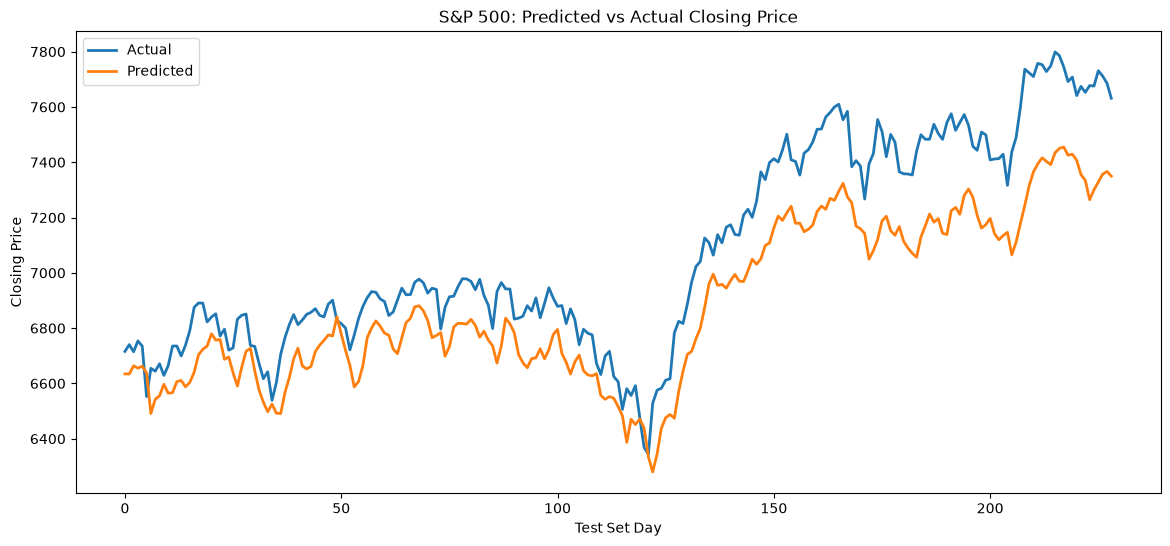

In [5]:
plt.figure(figsize=(14, 6))
plt.plot(actual, label="Actual", linewidth=2)
plt.plot(predictions, label="Predicted", linewidth=2)
plt.title("S&P 500: Predicted vs Actual Closing Price")
plt.xlabel("Test Set Day")
plt.ylabel("Closing Price")
plt.legend()
plt.show()

In [6]:
rmse = np.sqrt(mean_squared_error(actual, predictions))
mae = mean_absolute_error(actual, predictions)
mape = np.mean(np.abs((actual - predictions) / actual)) * 100

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f}%")

RMSE: 221.32
MAE: 196.09
MAPE: 2.72%


In [7]:
naive_predictions = actual[:-1]
naive_actual = actual[1:]

naive_rmse = np.sqrt(mean_squared_error(naive_actual, naive_predictions))
naive_mae = mean_absolute_error(naive_actual, naive_predictions)
naive_mape = np.mean(np.abs((naive_actual - naive_predictions) / naive_actual)) * 100

print(f"Naive Baseline RMSE: {naive_rmse:.2f}")
print(f"Naive Baseline MAE: {naive_mae:.2f}")
print(f"Naive Baseline MAPE: {naive_mape:.2f}%")

print(f"\nLSTM RMSE: {rmse:.2f}  vs  Naive RMSE: {naive_rmse:.2f}")
print(f"LSTM MAE:  {mae:.2f}  vs  Naive MAE:  {naive_mae:.2f}")

Naive Baseline RMSE: 58.50
Naive Baseline MAE: 44.69
Naive Baseline MAPE: 0.64%

LSTM RMSE: 221.32  vs  Naive RMSE: 58.50
LSTM MAE:  196.09  vs  Naive MAE:  44.69


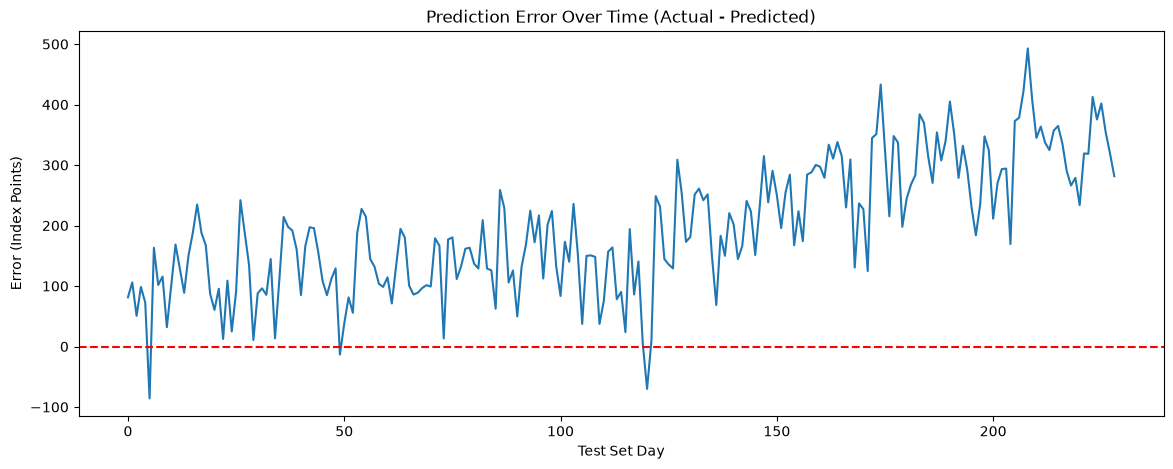

In [8]:
residuals = actual - predictions

plt.figure(figsize=(14, 5))
plt.plot(residuals)
plt.axhline(0, color="red", linestyle="--")
plt.title("Prediction Error Over Time (Actual - Predicted)")
plt.xlabel("Test Set Day")
plt.ylabel("Error (Index Points)")
plt.show()

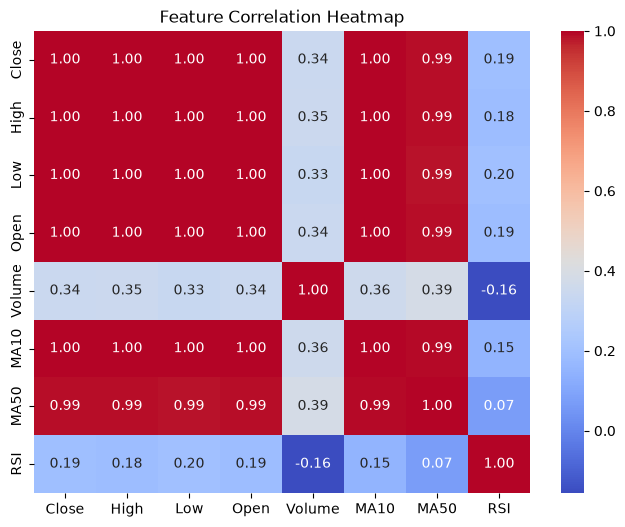

In [9]:
feature_cols = ["Close", "High", "Low", "Open", "Volume", "MA10", "MA50", "RSI"]
data_full = pd.read_csv("sp500_raw.csv")
data_full["MA10"] = data_full["Close"].rolling(window=10).mean()
data_full["MA50"] = data_full["Close"].rolling(window=50).mean()

delta = data_full["Close"].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain / avg_loss
data_full["RSI"] = 100 - (100 / (1 + rs))

data_full = data_full.dropna()

plt.figure(figsize=(8, 6))
sns.heatmap(data_full[feature_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

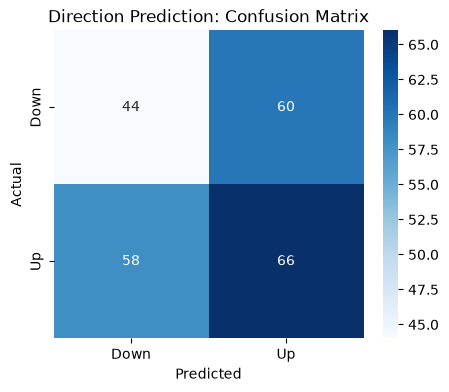

              precision    recall  f1-score   support

        Down       0.43      0.42      0.43       104
          Up       0.52      0.53      0.53       124

    accuracy                           0.48       228
   macro avg       0.48      0.48      0.48       228
weighted avg       0.48      0.48      0.48       228



In [10]:
actual_direction = np.where(np.diff(actual) > 0, 1, 0)
predicted_direction = np.where(np.diff(predictions) > 0, 1, 0)

cm = confusion_matrix(actual_direction, predicted_direction)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Down", "Up"], yticklabels=["Down", "Up"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Direction Prediction: Confusion Matrix")
plt.show()

print(classification_report(actual_direction, predicted_direction, target_names=["Down", "Up"]))

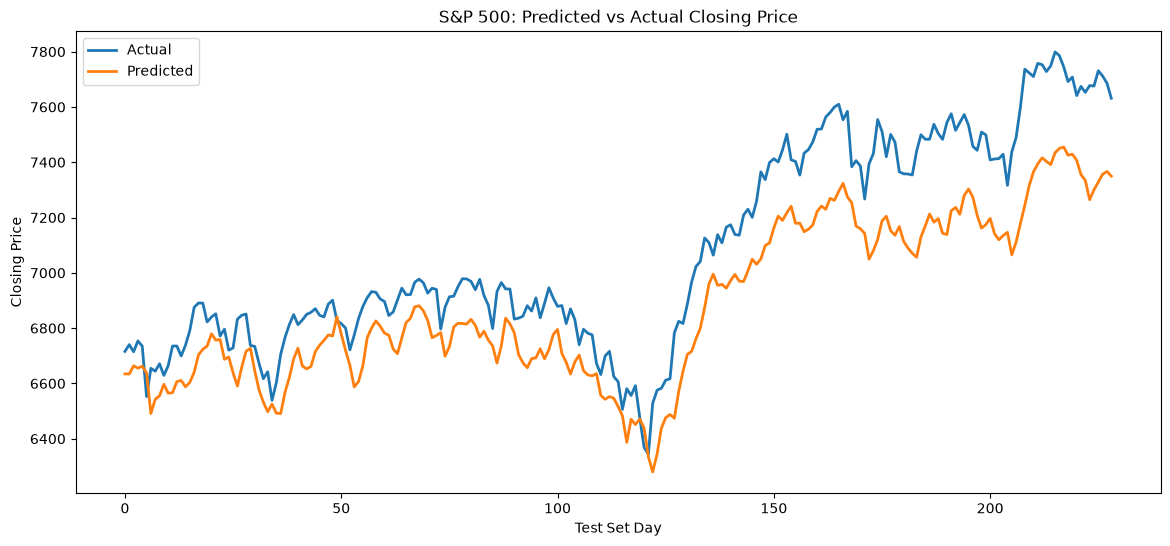

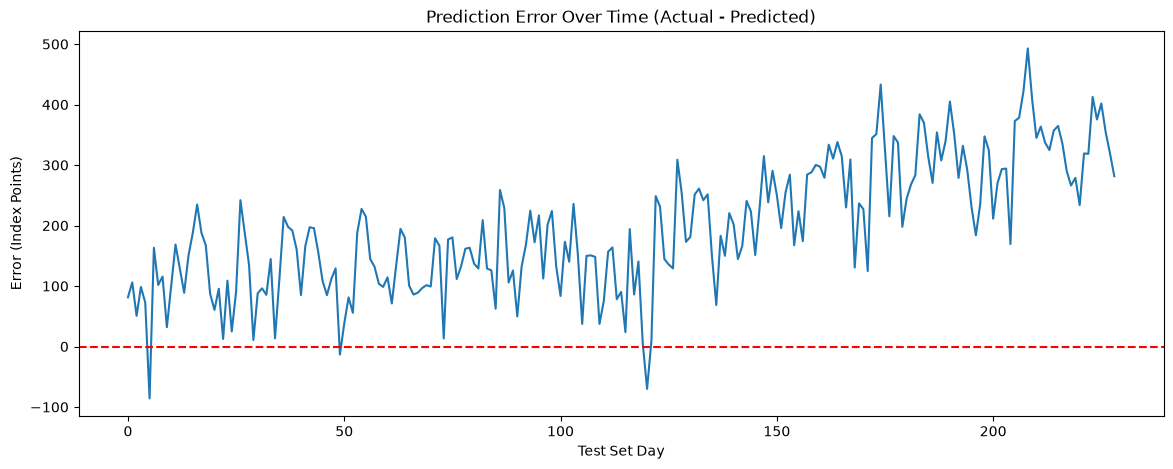

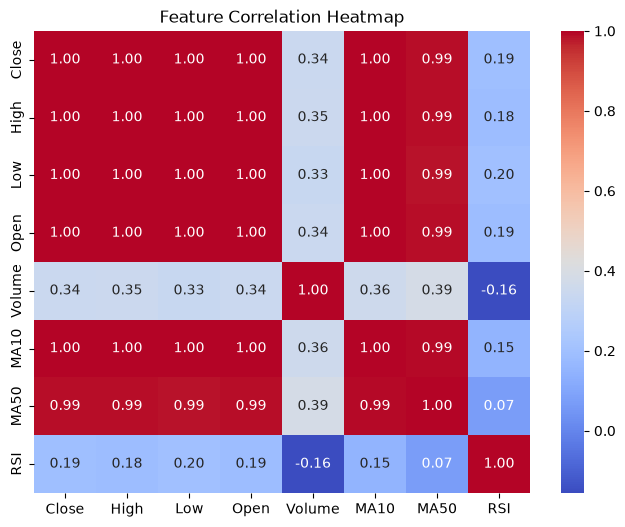

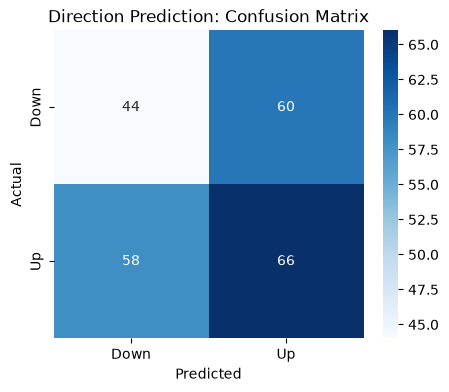

Saved to report_outputs/:
 - confusion_matrix.png
 - correlation_heatmap.png
 - metrics_summary.txt
 - predicted_vs_actual.png
 - residuals.png


In [11]:
import os

os.makedirs("report_outputs", exist_ok=True)

# 1. Predicted vs Actual
plt.figure(figsize=(14, 6))
plt.plot(actual, label="Actual", linewidth=2)
plt.plot(predictions, label="Predicted", linewidth=2)
plt.title("S&P 500: Predicted vs Actual Closing Price")
plt.xlabel("Test Set Day")
plt.ylabel("Closing Price")
plt.legend()
plt.savefig("report_outputs/predicted_vs_actual.png", dpi=300, bbox_inches="tight")
plt.show()

# 2. Residual plot
plt.figure(figsize=(14, 5))
plt.plot(residuals)
plt.axhline(0, color="red", linestyle="--")
plt.title("Prediction Error Over Time (Actual - Predicted)")
plt.xlabel("Test Set Day")
plt.ylabel("Error (Index Points)")
plt.savefig("report_outputs/residuals.png", dpi=300, bbox_inches="tight")
plt.show()

# 3. Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(data_full[feature_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.savefig("report_outputs/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# 4. Confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Down", "Up"], yticklabels=["Down", "Up"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Direction Prediction: Confusion Matrix")
plt.savefig("report_outputs/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# 5. Metrics summary as a text file
with open("report_outputs/metrics_summary.txt", "w") as f:
    f.write("S&P 500 LSTM Closing Price Predictor - Evaluation Summary\n")
    f.write("=" * 55 + "\n\n")
    f.write(f"RMSE: {rmse:.2f}\n")
    f.write(f"MAE: {mae:.2f}\n")
    f.write(f"MAPE: {mape:.2f}%\n\n")
    f.write("Naive Baseline (predict yesterday's price):\n")
    f.write(f"RMSE: {naive_rmse:.2f}\n")
    f.write(f"MAE: {naive_mae:.2f}\n")
    f.write(f"MAPE: {naive_mape:.2f}%\n\n")
    f.write("Direction Prediction Report:\n")
    f.write(classification_report(actual_direction, predicted_direction, target_names=["Down", "Up"]))

print("Saved to report_outputs/:")
for fname in os.listdir("report_outputs"):
    print(" -", fname)